# Priorization de communes

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [128]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.datasources import ocha, codab, floodscan, hydrosheds

In [133]:
adm3 = codab.load_codab(admin_level=3, aoi_only=True)
adm1 = codab.load_codab(admin_level=1, aoi_only=True)

In [119]:
river = hydrosheds.load_niger_river()
river_aoi = gpd.sjoin(river, adm3, how="inner", predicate="intersects")

In [55]:
adm3[adm3["ADM3_FR"] == "Sinder"]

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,VALIDTO,geometry
202,Sinder,NE006012006,Tillabéri,NE006012,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((1.16510 14.42749, 1.17548 14.42749, ..."


In [56]:
ciblage = floodscan.load_ciblage()

In [57]:
ciblage["commune"] = ciblage["Commune"].str.lower()

In [58]:
ciblage["commune"].sort_values().unique()

array(['abala', 'anzourou', 'ayerou', 'bana', 'banibangou', 'bankilaré',
       'bengou', 'bibiyergou', "birni n'gaouré", 'bitinkodji',
       'dan-kassari', 'dargol', 'dessa', 'diagourou', 'diantchandou',
       'dingazi', 'dioundiou', 'dogondoutchi', 'dogonkiria', 'dosso',
       'doumega', 'fabidji', 'fakara', 'falmey', 'falwel', 'farey',
       'filingué', 'garankédey', 'gaya', 'gollé', 'goroubankassam',
       'gorouol', 'gothèye', 'guilladjé', 'guéchémé', 'hamdallaye',
       'harikanassou', 'imanan', 'inatès', 'kankandi', 'karakara',
       'karguibangou', 'karma', 'kiota', 'kirtachi', 'kiéché', 'kokorou',
       'kollo', 'koré maïroua', 'kourfeye centre', 'kourteye', 'kouré',
       'koygolo', 'liboré', 'loga', 'makalondi', 'matankari', 'mokko',
       'méhana', "n'dounga", "n'gonga", 'namaro', 'niamey i', 'niamey ii',
       'niamey iii', 'niamey iv', 'niamey v', 'ouallam', 'ouro guéladjo',
       'sakoïra', 'sambéra', 'sanam', 'say', 'simiri', 'sinder',
       'sokorbé', 'sou

In [162]:
df = ocha.load_communes()
df = df.fillna(0)
for col in [col for col in df.columns if df[col].dtype == float]:
    df[col] = df[col].astype(int)

df["commune"] = df["COMMUNE"].str.lower()
df = df.merge(ciblage, how="left").drop(
    columns=["commune", "DEPARTEMENT", "COMMUNE"]
)

agences_cols = [
    "PAM",
    "FAO",
    "UNICEF",
    "PNUD",
    "OMS",
    "UNFPA",
    "HCR",
    "OIM",
    "SAP",
    "CRN",
    "DMN",
    "BM",
]
df["agences_total"] = df[agences_cols].sum(axis=1)

quartile_labels = [0, 1, 2, 3]
df["score_acces"] = df["Acces"]
df["score_agences"] = pd.qcut(
    df["agences_total"], q=4, labels=quartile_labels
).astype(int)
df["score_impact"] = pd.qcut(
    df["Maisons détruites"], q=4, labels=quartile_labels
).astype(int)
score_cols = [x for x in df.columns if "score" in x]
df["score_total"] = df[score_cols].sum(axis=1)
df = df.sort_values("score_total", ascending=False)
first_cols = ["ADM3_PCODE", "Département", "Commune", "Région"]
cols = first_cols + [x for x in df.columns if x not in first_cols]
df = df[cols]

/Users/tdowning/.pyenv/versions/pa-aa-ner-flooding/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [163]:
filename = "ner-ciblage-communes_avec-agences.xlsx"
df.to_excel(floodscan.PROC_FS_DIR / filename, index=False)

(-0.05552903579999999, 4.8236206858, 11.462306522549298, 15.912396359783367)

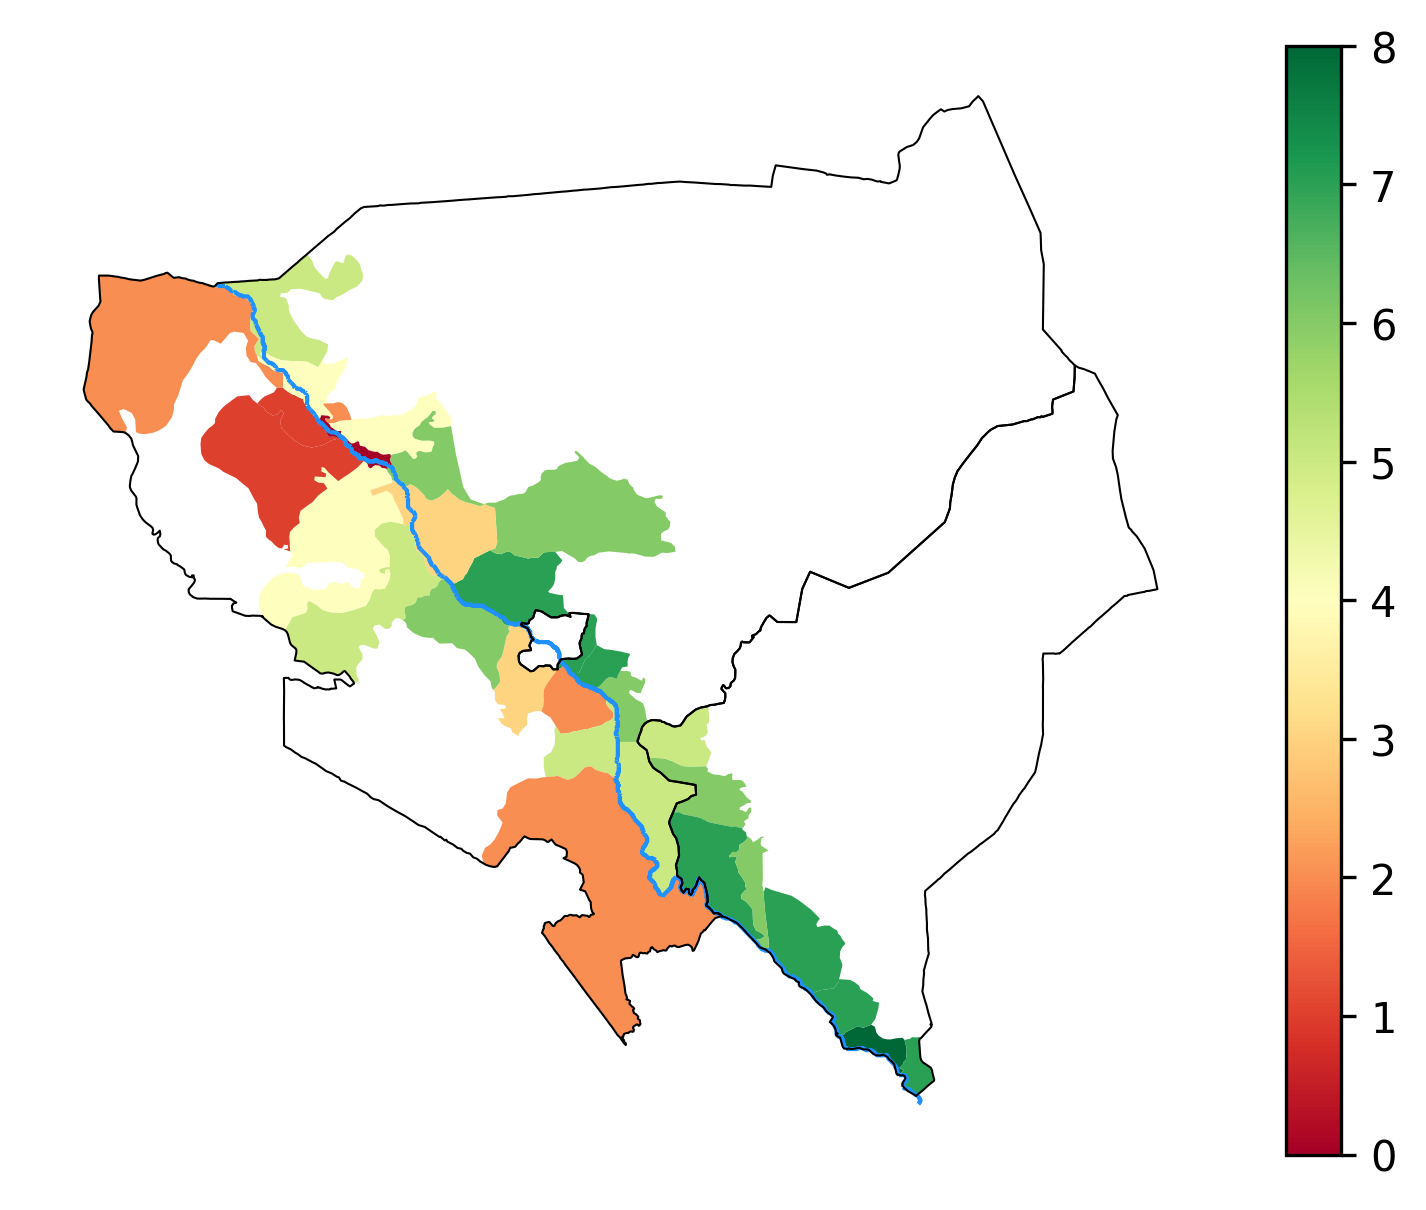

In [164]:
fig, ax = plt.subplots(dpi=300)
adm3.merge(df).plot(column="score_total", cmap="RdYlGn", legend=True, ax=ax)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
adm1.boundary.plot(ax=ax, linewidth=0.5, color="k")
ax.axis("off")